In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,12)

# import required libraries

In [2]:
from pathlib import Path
path = Path('/kaggle/input/datasets/bhaveshyadav111/shop-ecommerce')

In [3]:
import os
os.listdir(path)

['shop_smart_ecommerce.csv']

In [4]:
df = pd.read_csv(f'{path}/shop_smart_ecommerce.csv')

In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


# EDA

In [6]:
df.Revenue.value_counts() / len(df.Revenue)

Revenue
False    0.845255
True     0.154745
Name: count, dtype: float64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [8]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [9]:
df.nunique()

Administrative               27
Administrative_Duration    3335
Informational                17
Informational_Duration     1258
ProductRelated              311
ProductRelated_Duration    9551
BounceRates                1872
ExitRates                  4777
PageValues                 2704
SpecialDay                    6
Month                        10
OperatingSystems              8
Browser                      13
Region                        9
TrafficType                  20
VisitorType                   3
Weekend                       2
Revenue                       2
dtype: int64

<Axes: xlabel='VisitorType', ylabel='Count'>

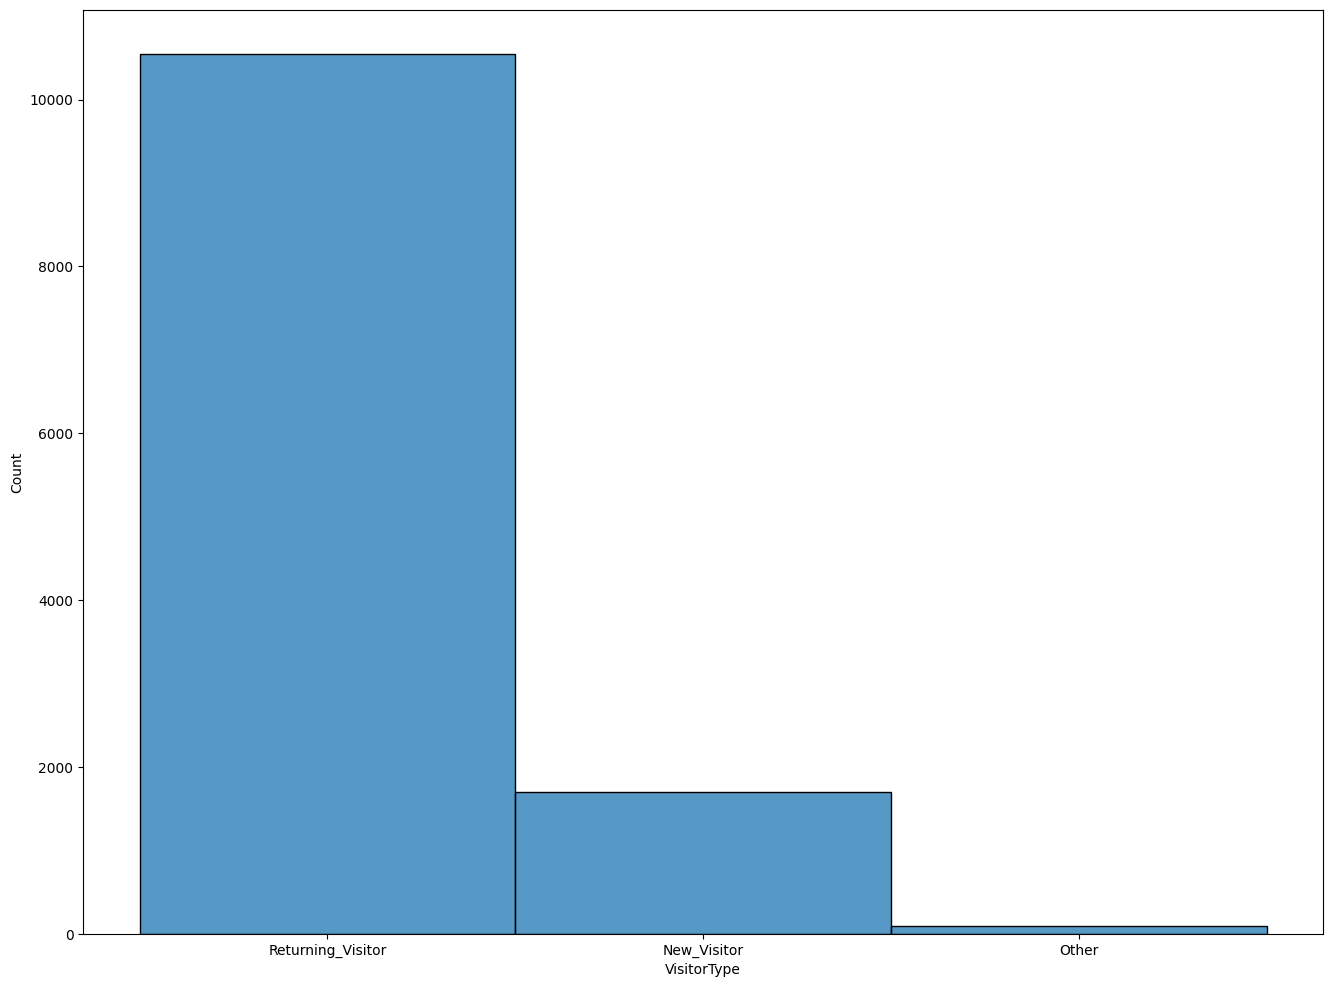

In [10]:
sns.histplot(df,x='VisitorType')

<Axes: xlabel='Month', ylabel='Count'>

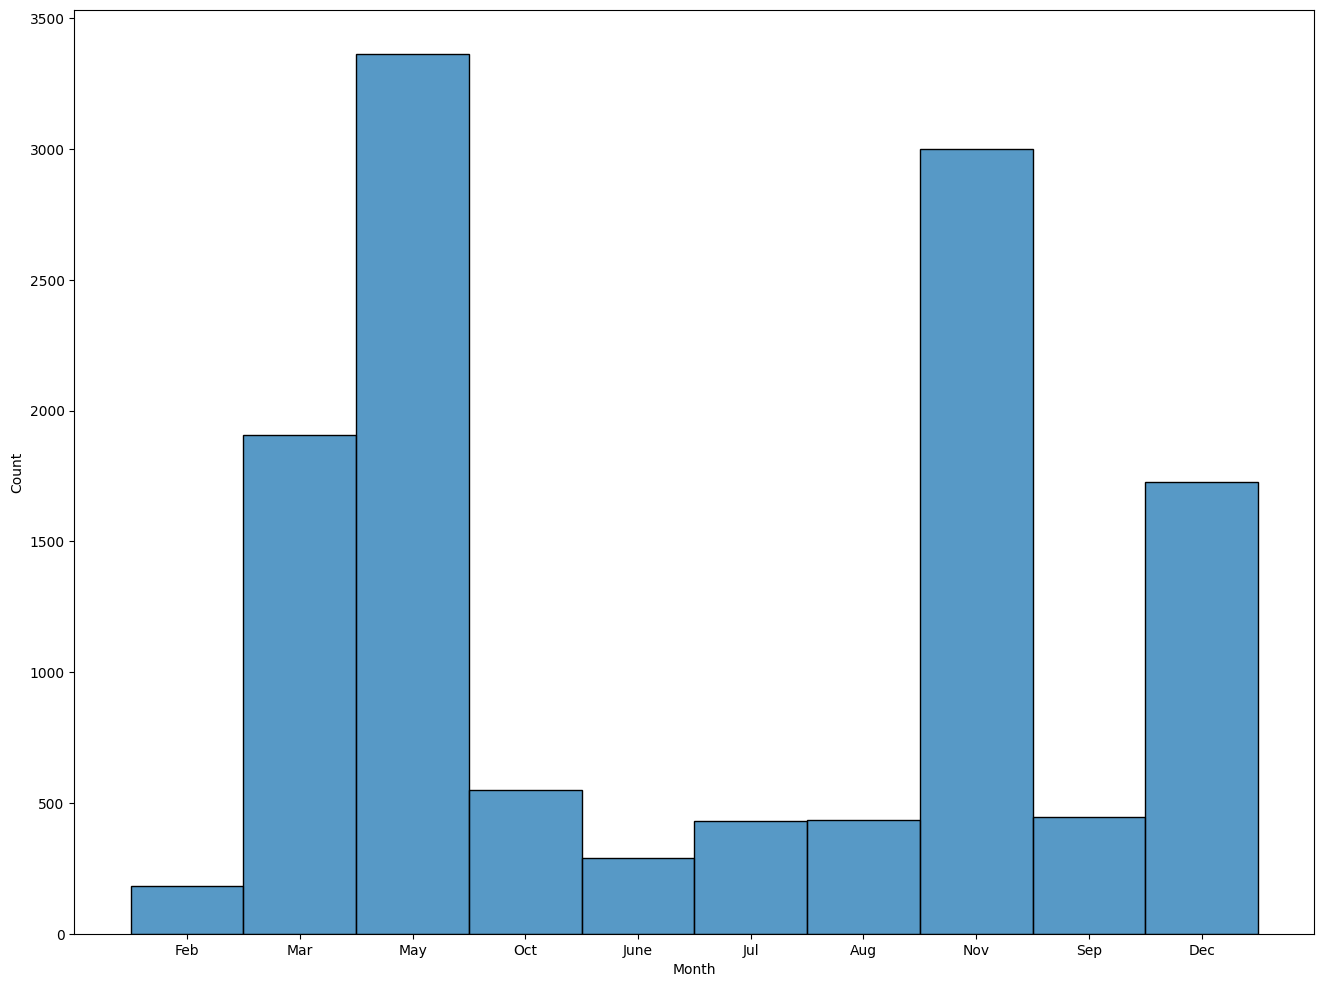

In [11]:
sns.histplot(df,x='Month')

In [12]:
df.corr(numeric_only=True)['Revenue'].sort_values(ascending=False)

Revenue                    1.000000
PageValues                 0.492569
ProductRelated             0.158538
ProductRelated_Duration    0.152373
Administrative             0.138917
Informational              0.095200
Administrative_Duration    0.093587
Informational_Duration     0.070345
Weekend                    0.029295
Browser                    0.023984
TrafficType               -0.005113
Region                    -0.011595
OperatingSystems          -0.014668
SpecialDay                -0.082305
BounceRates               -0.150673
ExitRates                 -0.207071
Name: Revenue, dtype: float64

In [13]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

In [14]:
df['Weekend'] = LabelEncoder().fit_transform(df['Weekend'])

In [15]:
to_1hot = ['Month','VisitorType']
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore').fit(df[to_1hot])

In [16]:
enc_cols = encoder.get_feature_names_out(to_1hot)
df[enc_cols] = encoder.transform(df[to_1hot])
df.drop(columns=to_1hot,inplace=True)

In [17]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend',
       'Revenue', 'Month_Aug', 'Month_Dec', 'Month_Feb', 'Month_Jul',
       'Month_June', 'Month_Mar', 'Month_May', 'Month_Nov', 'Month_Oct',
       'Month_Sep', 'VisitorType_New_Visitor', 'VisitorType_Other',
       'VisitorType_Returning_Visitor'],
      dtype='object')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 29 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

<Axes: xlabel='TrafficType', ylabel='Revenue'>

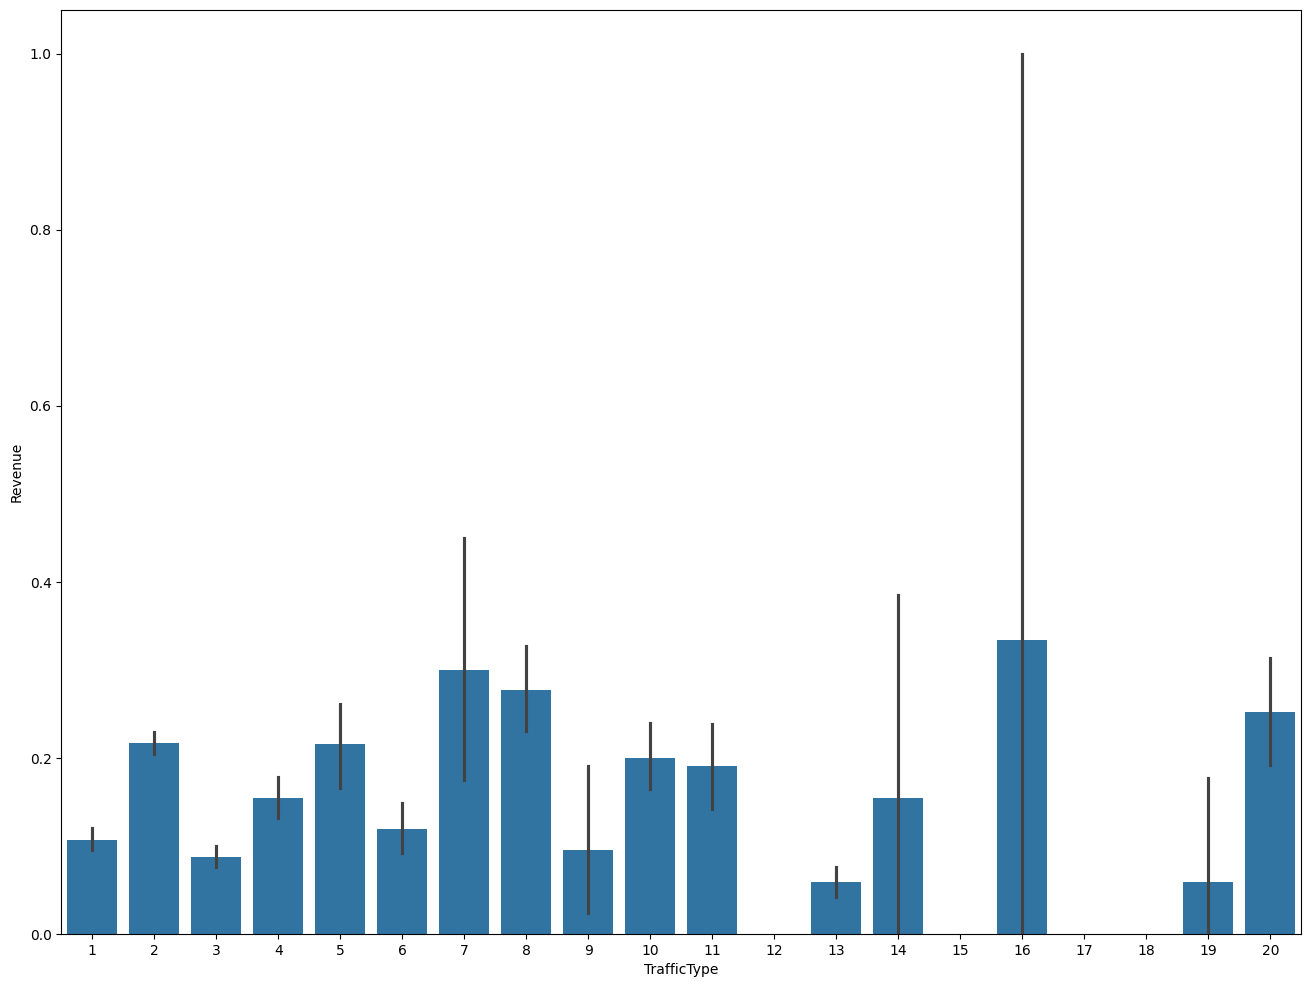

In [19]:
sns.barplot(df,x='TrafficType',y='Revenue')

<Axes: xlabel='BounceRates', ylabel='Count'>

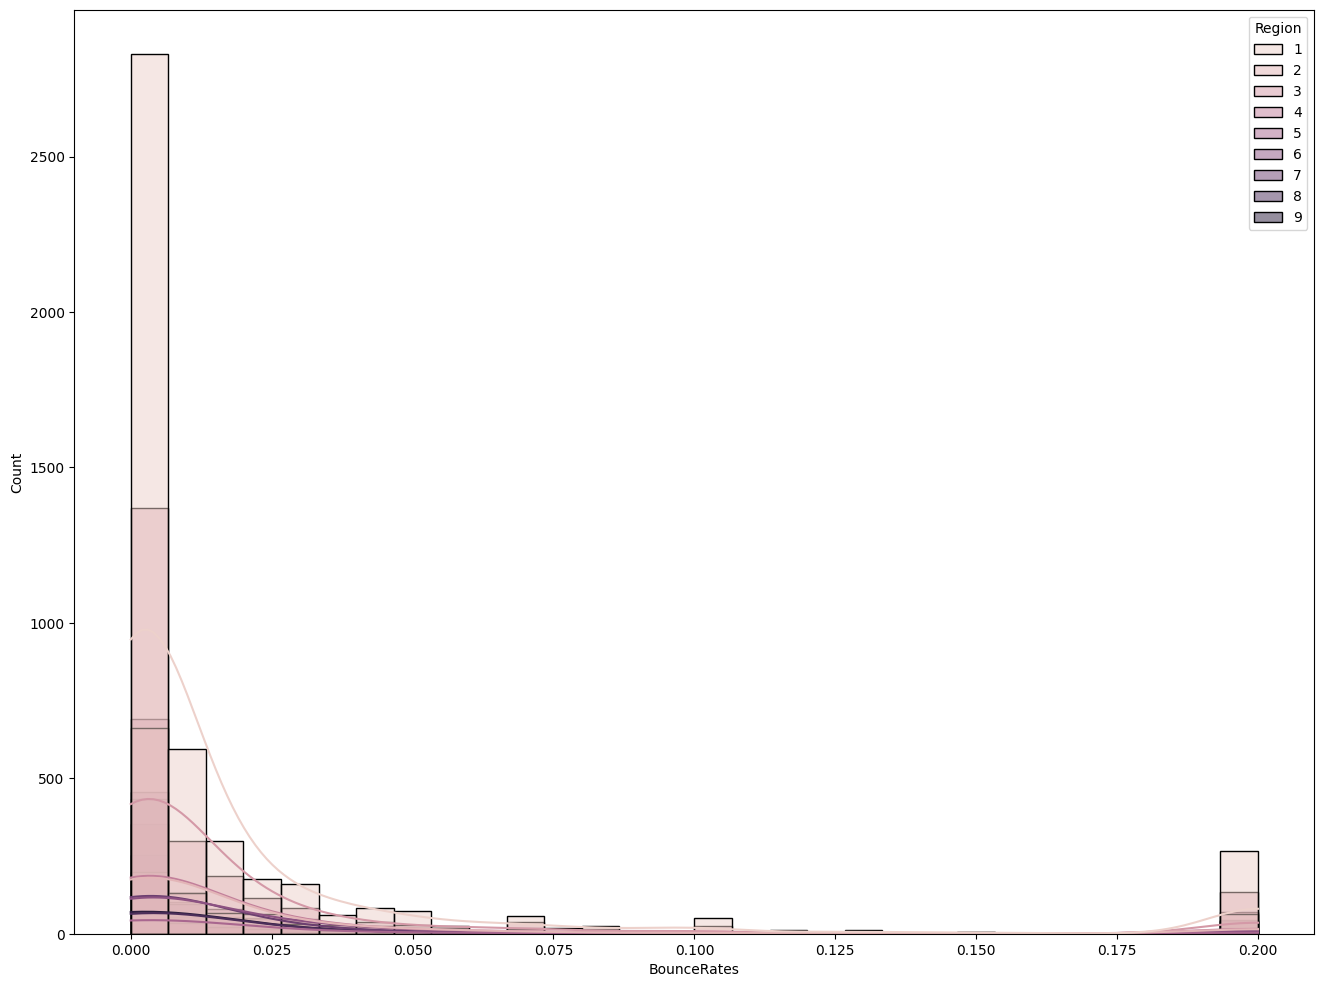

In [20]:
sns.histplot(df,x='BounceRates',hue='Region',kde=True,color='red',bins=30)

<Axes: xlabel='Revenue', ylabel='PageValues'>

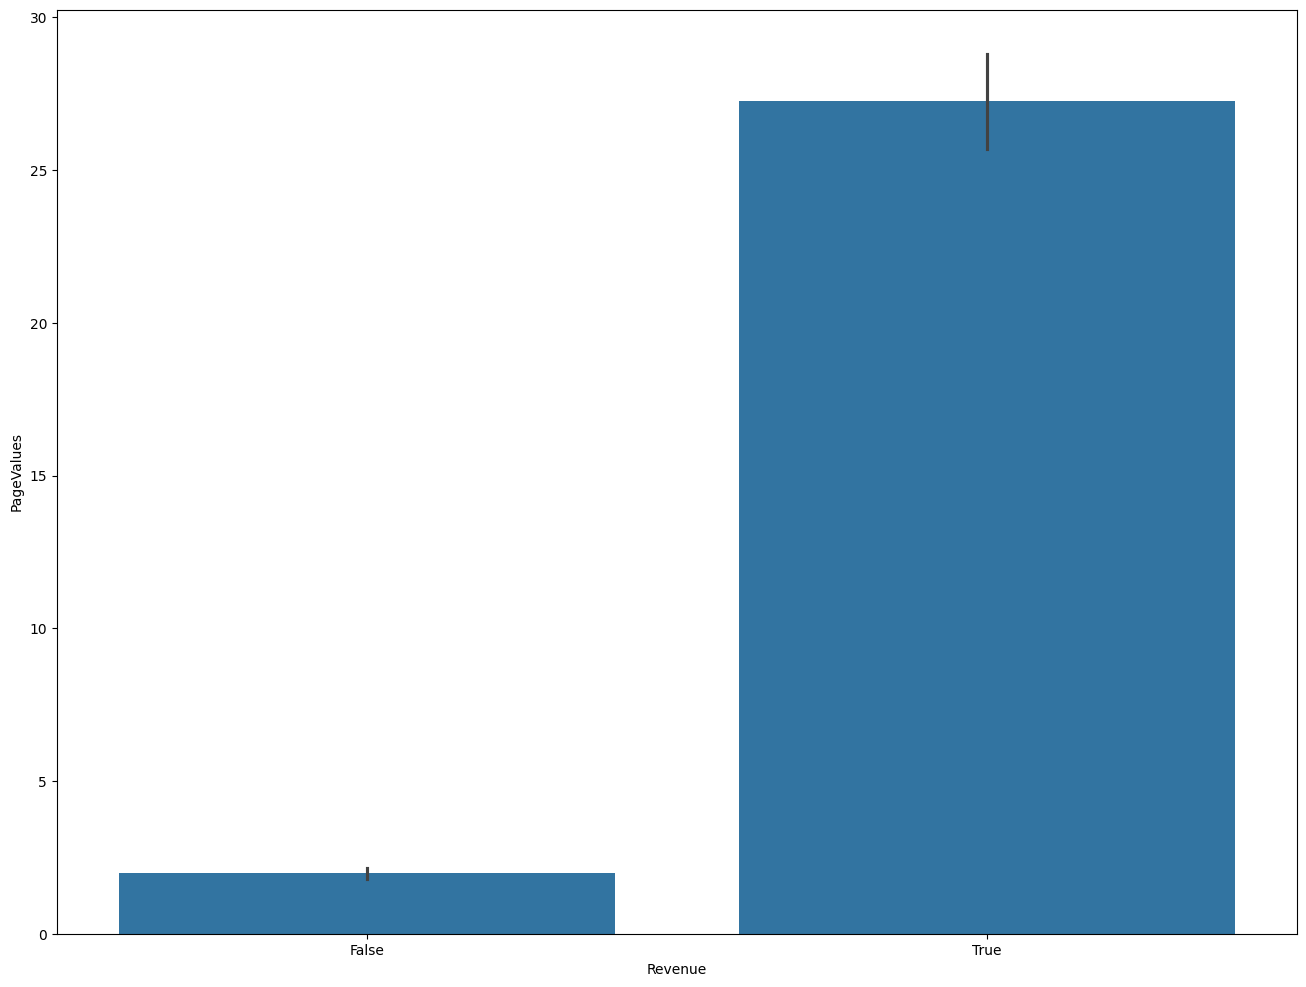

In [21]:
sns.barplot(df,x='Revenue',y='PageValues')

<Axes: >

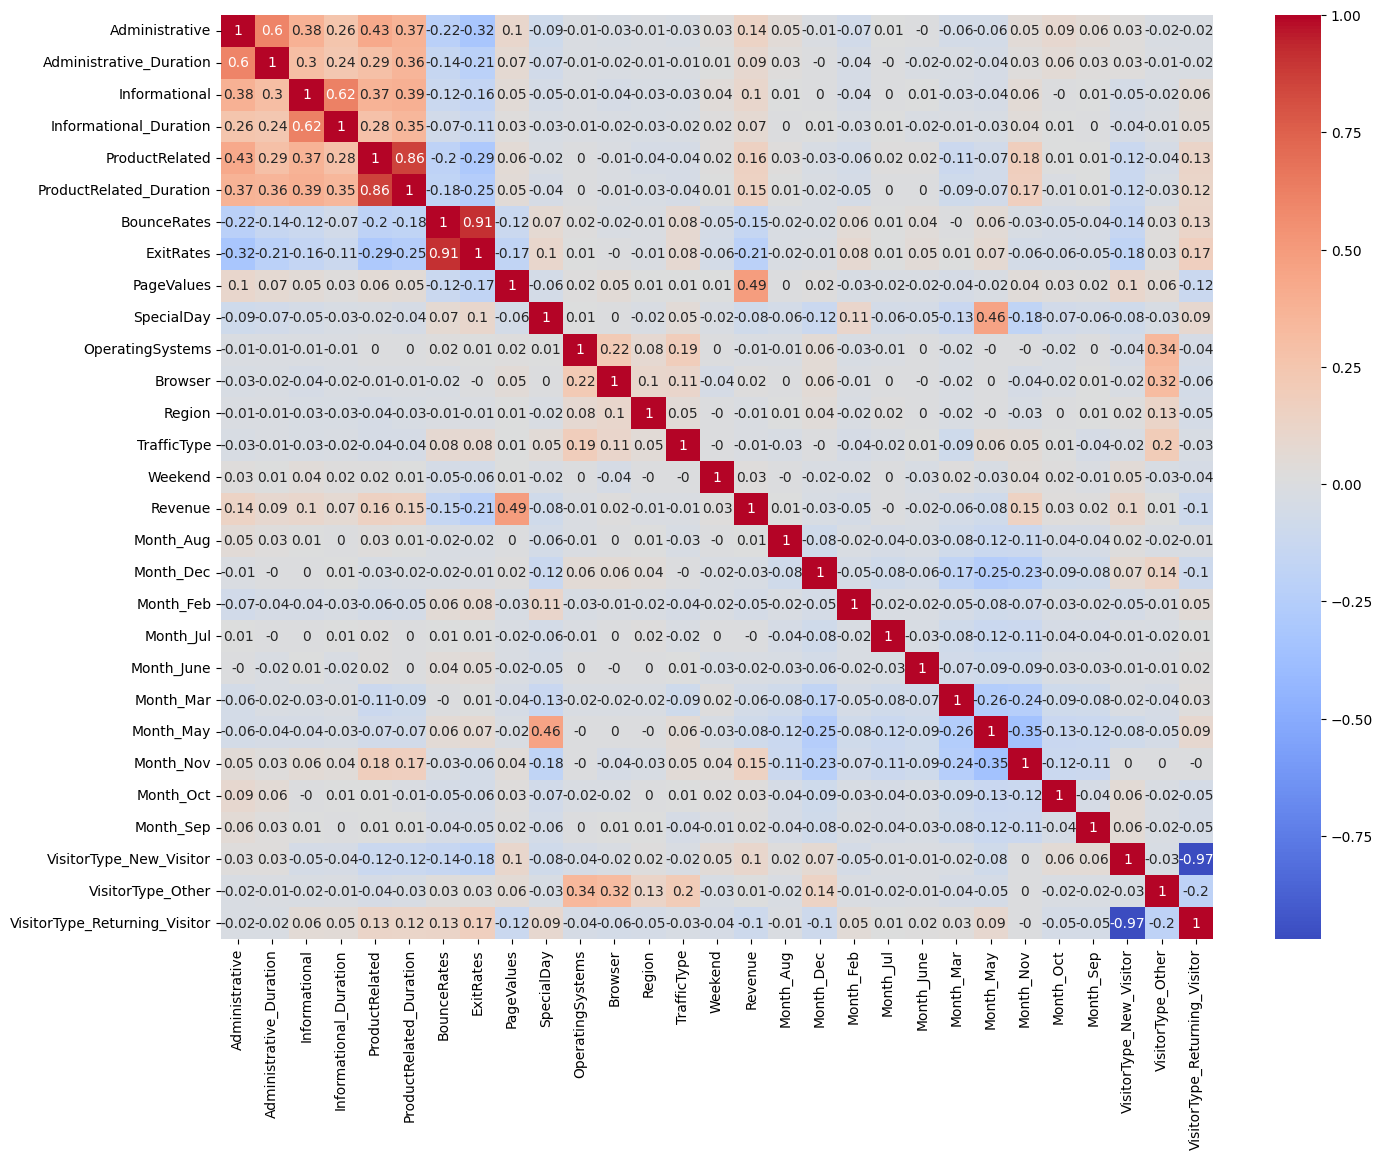

In [22]:
sns.heatmap(df.corr().round(2) ,annot=True,cmap='coolwarm')

# Figure out Input and output features 

In [23]:
X = df.drop(columns=['Revenue'])
y = 'Revenue'
y = df[y]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)

In [24]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Administrative                 12330 non-null  int64  
 1   Administrative_Duration        12330 non-null  float64
 2   Informational                  12330 non-null  int64  
 3   Informational_Duration         12330 non-null  float64
 4   ProductRelated                 12330 non-null  int64  
 5   ProductRelated_Duration        12330 non-null  float64
 6   BounceRates                    12330 non-null  float64
 7   ExitRates                      12330 non-null  float64
 8   PageValues                     12330 non-null  float64
 9   SpecialDay                     12330 non-null  float64
 10  OperatingSystems               12330 non-null  int64  
 11  Browser                        12330 non-null  int64  
 12  Region                         12330 non-null 

# Model training

In [25]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score,confusion_matrix,f1_score
gnb = GaussianNB().fit(x_train,y_train)

print(gnb.score(x_test,y_test))
y_pred = gnb.predict(x_test)
f1_score(y_test,y_pred)

0.8017031630170316


0.4736275565123789

In [26]:
# K neighbours
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)

knn = KNeighborsClassifier().fit(x_train,y_train)

print(knn.score(x_test,y_test))
y_pred = knn.predict(x_test)
f1_score(y_test,y_pred)

0.8678021086780211


0.41155234657039713

In [27]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier,plot_tree
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [28]:
y_pred_train = model.predict(x_train)
y_pred_test = model.predict(x_test)

In [29]:
print("train f1 : " ,f1_score(y_train,y_pred_train))
print("test f1 : " ,f1_score(y_test,y_pred_test))

train f1 :  1.0
test f1 :  0.5489130434782609


In [30]:
confusion_matrix(y_test,y_pred_test)

array([[1932,  183],
       [ 149,  202]])

In [31]:
model.classes_.tolist()


[False, True]

In [32]:
model.get_depth()

26

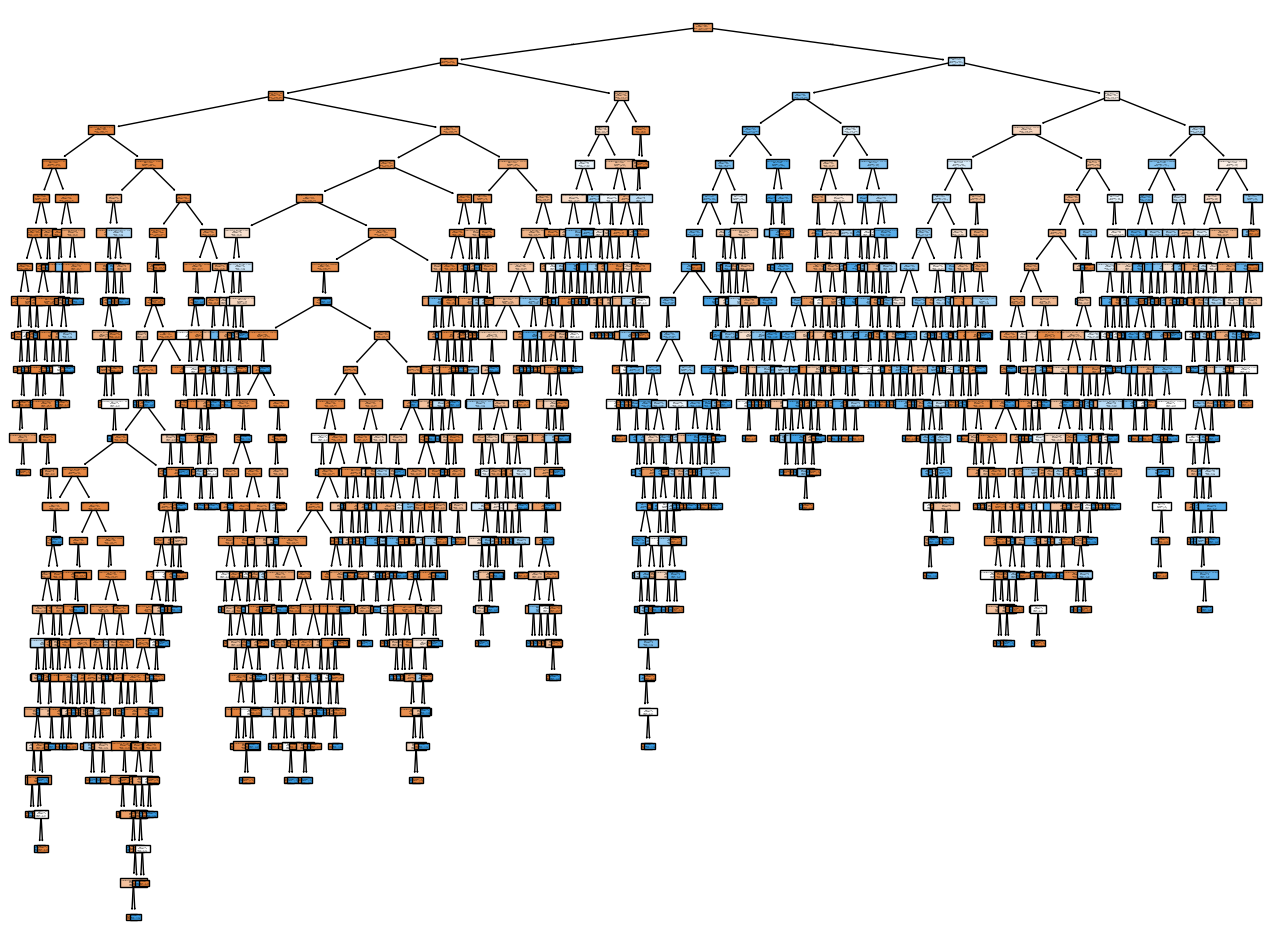

In [33]:
plot_tree(model,feature_names=x_train.columns.tolist(),filled=True,class_names=['False', 'True'])
plt.show()

# Hyperparameters Tuning

In [34]:
depth = [d for d in range(3,26)]
best_score = 0;
best_d_model = 0
best_depth = 0
for d in depth : 
    model = DecisionTreeClassifier(max_depth=d)
    model.fit(x_train,y_train)

    score = model.score(x_test,y_test)

    if(score > best_score):
        best_d_model = model
        best_score = score
        best_depth = d
    

In [35]:
print("for depth {} the best score is {}".format(best_depth,best_score*100))

for depth 4 the best score is 90.51094890510949


In [36]:
best_d_model

DecisionTreeClassifier(max_depth=4)

In [37]:
path = model.cost_complexity_pruning_path(x_train,y_train)
cc = path.ccp_alphas

In [38]:
ccp_list = cc
best_score = 0;
best_ccp = 0
for c in ccp_list : 
    model = DecisionTreeClassifier(ccp_alpha=c)
    model.fit(x_train,y_train)

    score = model.score(x_test,y_test)

    if(score > best_score):
        best_model = model
        best_score = score
        best_ccp = c

In [39]:
print(best_score)
print(best_ccp)

0.9051094890510949
0.00048363257288528436


In [40]:
final = DecisionTreeClassifier(ccp_alpha=0.00048363257288528436,random_state=1).fit(x_train,y_train)

In [41]:
final

DecisionTreeClassifier(ccp_alpha=0.00048363257288528436, random_state=1)

Here when ccp_alpha is (0.0009614949823057335) score of model = 90.47 % 

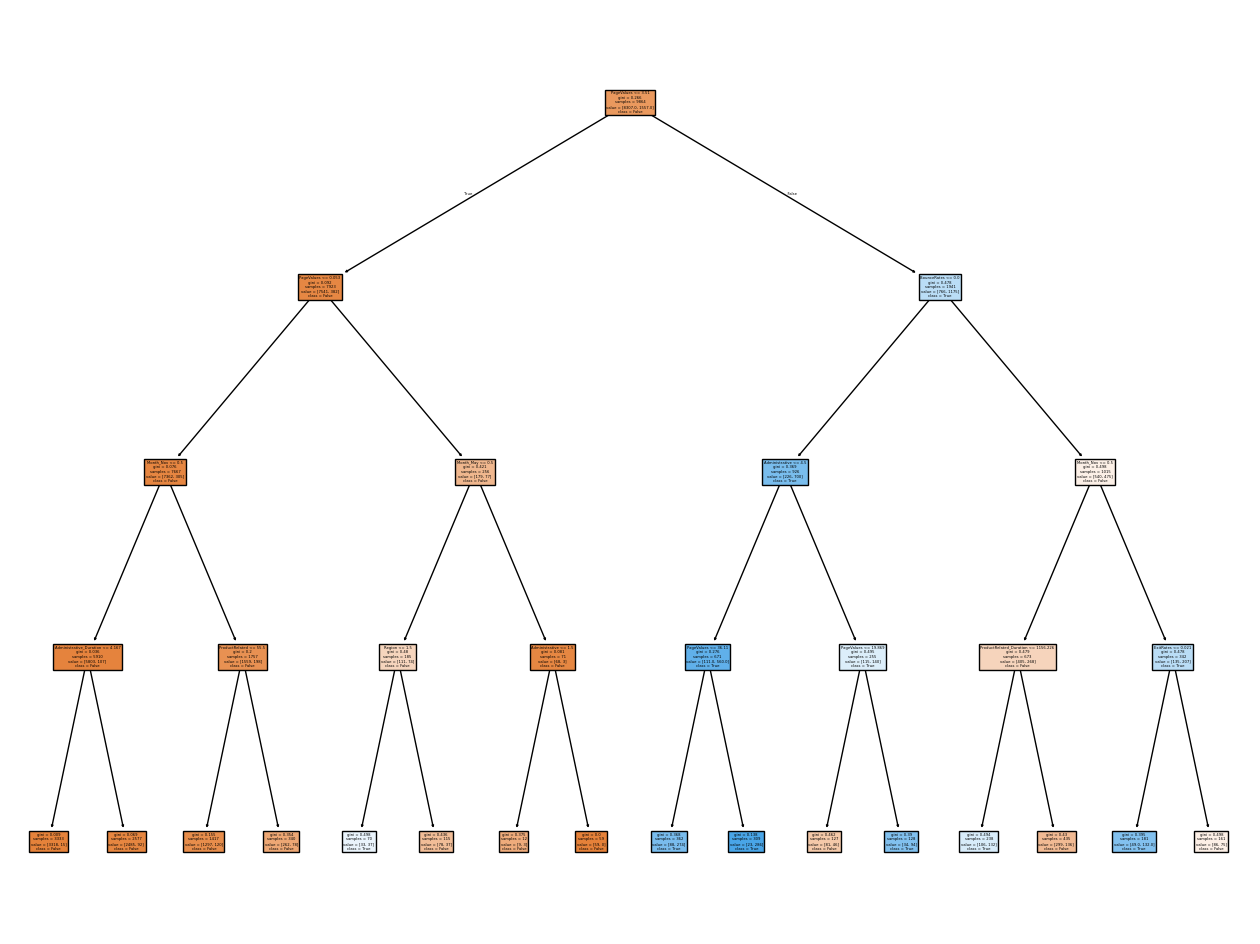

In [42]:
plot_tree(best_d_model,feature_names=x_train.columns.tolist(),filled=True,class_names=['False', 'True'])
plt.show()

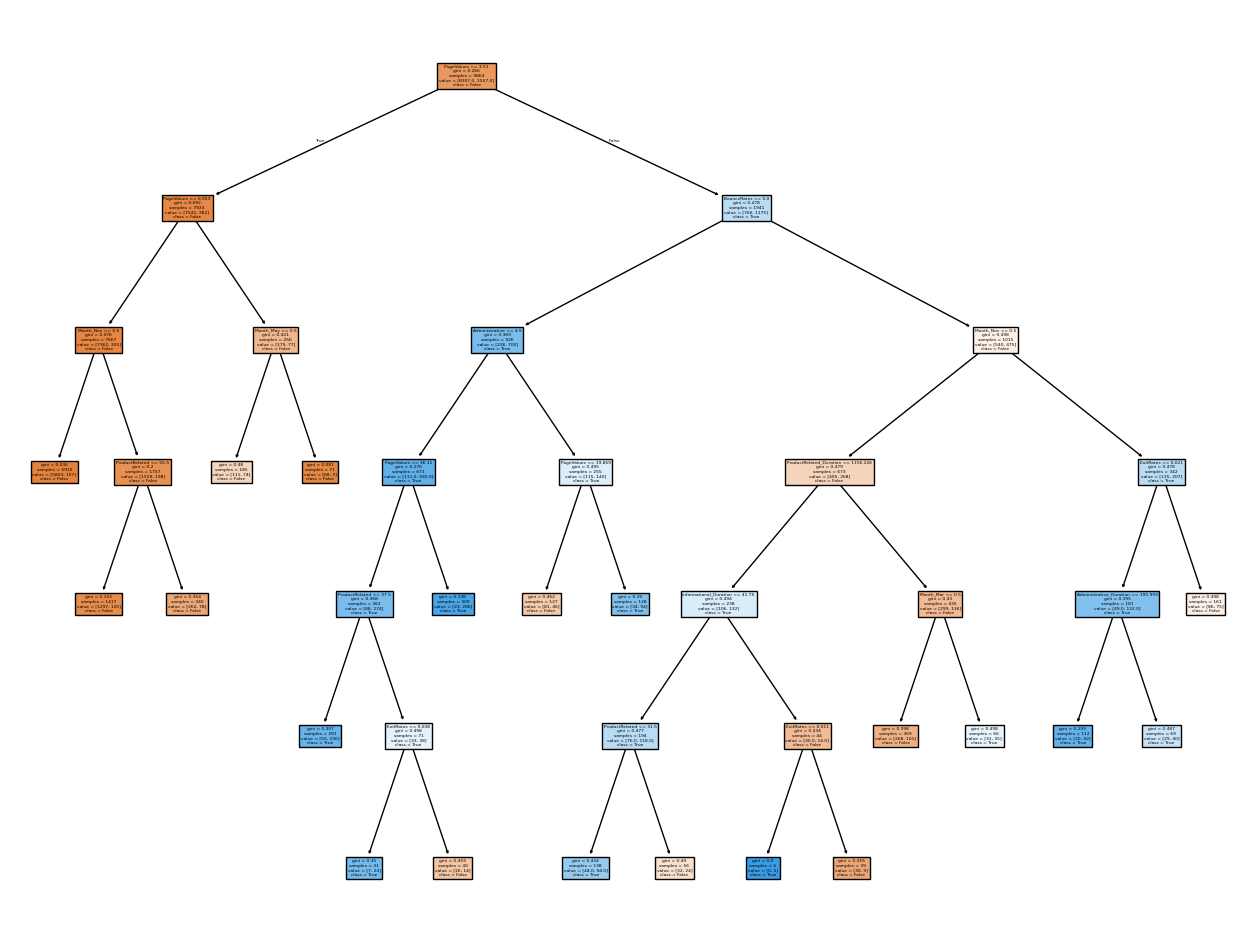

In [43]:
plot_tree(final,feature_names=x_train.columns.tolist(),filled=True,class_names=['False', 'True'])
plt.show()

In [44]:
from sklearn.ensemble import RandomForestClassifier

In [45]:
rfc = RandomForestClassifier(max_depth=4).fit(x_train,y_train)

In [46]:
rfc.score(x_test,y_test)

0.8763179237631792

Decision Tree Performes Best amoung Naive Bayes , KNeighbors, Random forest